In [15]:
!pip install pandas
!pip install "numpy<2.0"
!pip install seaborn
!pip install matplotlib
!pip install awpy
!pip install scipy
!pip install statsmodels

  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.55.1 requires numpy<1.22,>=1.18, but you have numpy 2.2.6 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.2.6 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\asus\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


  Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl (15.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.55.1 requires numpy<1.22,>=1.18, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\asus\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\asus\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\asus\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\asus\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\asus\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\asus\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [18]:
pip install --upgrade matplotlib awpy scikit-learn scipy


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 3.4 MB/s eta 0:00:03
   ------- -------------------------------- 1.6/8.1 MB 3.2 MB/s eta 0:00:03
   ------------ --------------------------- 2.6/8.1 MB 3.8 MB/s eta 0:00:02
   ------------------ --------------------- 3.7/8.1 MB 4.1 MB/s eta 0:00:02
   ------------------------ --------------- 5.0/8.1 MB 4.6 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.1 MB 5.0 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.1 MB 5.5 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 5.3 MB/s  0:00:01
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   --------- ------------------------------ 2.1/8.9 MB 11.8 MB/s eta 0:00:01
   ----------------- ---------------------- 3.9/8.9 MB 12.4 MB/s eta 0:00:01
   ------------------------ -----

  You can safely remove it manually.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\asus\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [1]:
# Core libraries for data handling and numerics
import os
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# The core parsing library for CS:GO demos
from awpy.parser import DemoParser

# Statistical tools for time series analysis
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from scipy.stats import levene

# Set plotting style for better aesthetics
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [16]:
!pip list

Package                      Version
---------------------------- --------------
absl-py                      2.3.1
aiohttp                      3.8.1
aiohttp-wsgi                 0.10.0
aiosignal                    1.2.0
altair                       5.5.0
anyio                        4.7.0
appdirs                      1.4.4
argon2-cffi                  23.1.0
argon2-cffi-bindings         21.2.0
arrow                        1.3.0
asgiref                      3.5.0
asttokens                    3.0.0
astunparse                   1.6.3
async-lru                    2.0.4
async-timeout                4.0.2
attrs                        24.3.0
audioread                    2.1.9
awpy                         1.2.3
babel                        2.16.0
backcall                     0.2.0
beautifulsoup4               4.12.3
bleach                       6.2.0
blinker                      1.9.0
cachetools                   5.5.0
catboost                     1.2.8
certifi                      2021.10.8

In [20]:
def parse_player_stats_from_demo(demofile_path, player_name):
    """
    Parses a CS:GO demo file and extracts round-by-round stats for a specific player.
    This version looks for kills within the round data structure.
    Args:
        demofile_path (str): The full path to the .dem file.
        player_name (str): The in-game name of the player to track.
    Returns:
        pd.DataFrame: A DataFrame with stats for the specified player.
    """
    print(f"Parsing {demofile_path}...")
    try:
        demo_parser = DemoParser(demofile=demofile_path, parse_rate=128, trade_time=5)
        data = demo_parser.parse()
    except Exception as e:
        print(f"Error parsing demo file: {e}")
        return pd.DataFrame()
    
    # Step 1: Find the player's Steam ID
    player_steam_id = None
    if data.get("gameRounds"):
        all_players_first_round = data["gameRounds"][0].get('ctSide', {}).get('players', []) + \
                                  data["gameRounds"][0].get('tSide', {}).get('players', [])
        
        for p in all_players_first_round:
            if p and p.get('playerName') == player_name:
                player_steam_id = p.get('steamID')
                break
            
    if not player_steam_id:
        print(f"Warning: Player '{player_name}' not found in {demofile_path}.")
        return pd.DataFrame()
    
    print(f"Found player Steam ID: {player_steam_id}")
    
    # Step 2: Extract stats from each round
    final_stats_list = []
    
    if data.get("gameRounds"):
        for r in data["gameRounds"]:
            round_num = r.get("roundNum")
            if round_num is None:
                continue
            
            kills = 0
            headshots = 0
            
            # Check if kills are stored within the round data
            if r.get("kills"):
                for kill in r["kills"]:
                    # Convert to strings for comparison
                    if str(kill.get("attackerSteamID")) == str(player_steam_id):
                        kills += 1
                        if kill.get("isHeadshot", False) or kill.get("headshot", False):
                            headshots += 1
            
            # Alternative: Check frames for kills
            elif r.get("frames"):
                for frame in r["frames"]:
                    if frame.get("kills"):
                        for kill in frame["kills"]:
                            if str(kill.get("attackerSteamID")) == str(player_steam_id):
                                kills += 1
                                if kill.get("isHeadshot", False) or kill.get("headshot", False):
                                    headshots += 1
            
            # Another alternative: Check player-specific stats in round
            else:
                # Look through both teams for the player's stats
                for side in ['ctSide', 'tSide']:
                    if r.get(side) and r[side].get('players'):
                        for player in r[side]['players']:
                            if player and str(player.get('steamID')) == str(player_steam_id):
                                # Try to get kills from player stats
                                kills = player.get('kills', 0) if player.get('kills') is not None else 0
                                headshots = player.get('headshots', 0) if player.get('headshots') is not None else 0
                                break
            
            final_stats_list.append({
                "match_id": data.get("mapName", "UnknownMap"),
                "round_num": round_num,
                "player_name": player_name,
                "kills": kills,
                "headshots": headshots
            })
    
    final_df = pd.DataFrame(final_stats_list)
    final_df = final_df.sort_values(by="round_num").reset_index(drop=True)
    
    print(f"Total kills found for {player_name}: {final_df['kills'].sum()}")
    return final_df

In [21]:
# --- Main Parsing Logic ---
DEMO_FOLDER = "demos"
PLAYER_TO_ANALYZE = "s1mple"

all_demos = sorted([os.path.join(DEMO_FOLDER, f) for f in os.listdir(DEMO_FOLDER) if f.endswith(".dem")])

# Loop through all demos and concatenate the results
player_df_list = [parse_player_stats_from_demo(demo, PLAYER_TO_ANALYZE) for demo in all_demos]
full_player_df = pd.concat(player_df_list, ignore_index=True)

print(f"\nParsing complete for {PLAYER_TO_ANALYZE}!")
print("Here are the first few rows of your data:")
full_player_df.head()

Parsing demos\g2-vs-natus-vincere-m1-ancient.dem...
Found player Steam ID: 76561198034202275
Total kills found for s1mple: 32
Parsing demos\g2-vs-natus-vincere-m2-nuke.dem...
Found player Steam ID: 76561198034202275
Total kills found for s1mple: 39
Parsing demos\natus-vincere-vs-heroic-ancient.dem...
Found player Steam ID: 76561198034202275
Total kills found for s1mple: 21
Parsing demos\natus-vincere-vs-nip-m1-nuke.dem...
Found player Steam ID: 76561198034202275
Total kills found for s1mple: 23
Parsing demos\natus-vincere-vs-nip-m2-overpass.dem...
Found player Steam ID: 76561198034202275
Total kills found for s1mple: 20
Parsing demos\natus-vincere-vs-virtus-pro-overpass.dem...
Found player Steam ID: 76561198034202275
Total kills found for s1mple: 22
Parsing demos\natus-vincere-vs-vitality-m1-dust2.dem...
Found player Steam ID: 76561198034202275
Total kills found for s1mple: 22
Parsing demos\natus-vincere-vs-vitality-m2-nuke.dem...
Found player Steam ID: 76561198034202275
Total kills fo

,match_id,round_num,player_name,kills,headshots
0,de_ancient,1,s1mple,2,2
1,de_ancient,2,s1mple,2,0
2,de_ancient,3,s1mple,0,0
3,de_ancient,4,s1mple,0,0
4,de_ancient,5,s1mple,1,0


In [22]:
# Create a continuous round number for the entire tournament
full_player_df = full_player_df.sort_values(by=['match_id', 'round_num']).reset_index(drop=True)
full_player_df['tournament_round_num'] = full_player_df.index

# Calculate our key performance indicator: Headshot Percentage per Round
# We use a fillna(0) to handle rounds with zero kills, where HS% is undefined but should be 0.
full_player_df['hs_percentage'] = (full_player_df['headshots'] / full_player_df['kills']).fillna(0)

# Clean up for analysis
final_ts = full_player_df[['tournament_round_num', 'hs_percentage']].set_index('tournament_round_num')

print(f"Created a time series with {len(final_ts)} total rounds for {PLAYER_TO_ANALYZE}.")
final_ts.head()

Created a time series with 221 total rounds for s1mple.


,hs_percentage
tournament_round_num,
0,1.0
1,1.0
2,0.0
3,1.0
4,0.0


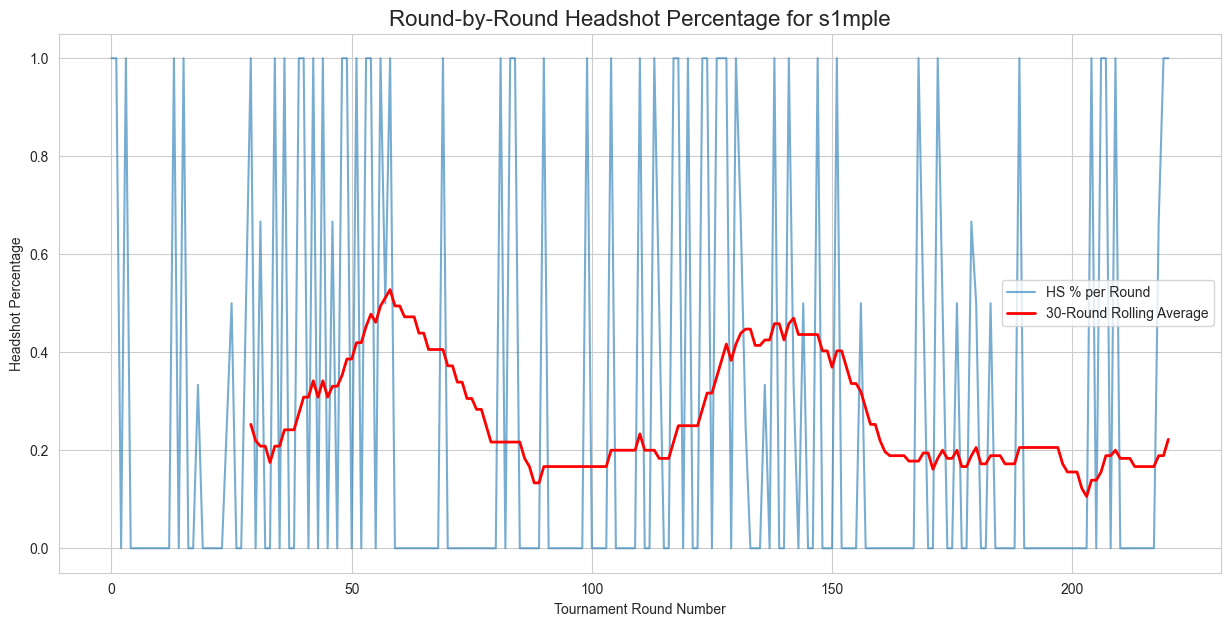

In [23]:
# Plot the raw time series of headshot percentage across the entire tournament
plt.figure(figsize=(15, 7))
plt.plot(final_ts.index, final_ts['hs_percentage'], label='HS % per Round', alpha=0.6)
plt.title(f'Round-by-Round Headshot Percentage for {PLAYER_TO_ANALYZE}', fontsize=16)
plt.xlabel('Tournament Round Number')
plt.ylabel('Headshot Percentage')

# Add a rolling average to visualize the trend
final_ts['rolling_avg'] = final_ts['hs_percentage'].rolling(window=30).mean()\

plt.plot(final_ts.index, final_ts['rolling_avg'], label='30-Round Rolling Average', color='red', linewidth=2)

plt.legend()
plt.show()

--- Variance Analysis ---
Variance in Early Tournament: 0.1830
Variance in Late Tournament:  0.1728

Levene's Test for Equal Variances:
P-value: 0.8450
Result: The difference in variances is not statistically significant. (Hypothesis Not Supported)

--- Autocorrelation Analysis ---


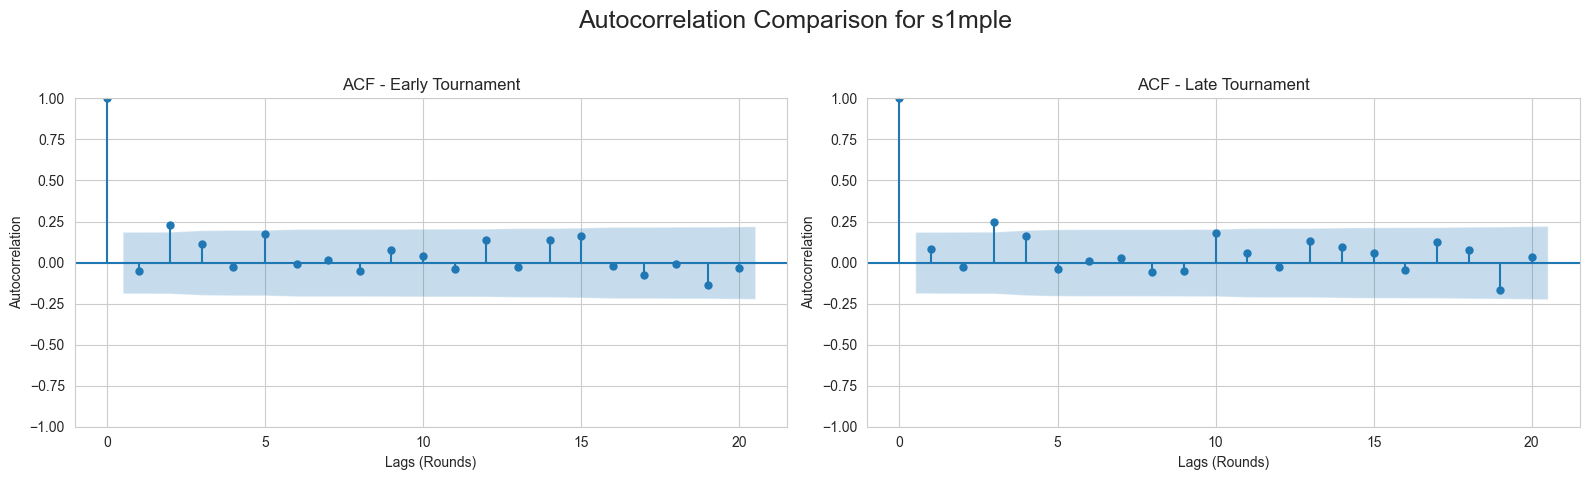

In [24]:
# Split the data into two halves
split_point = len(final_ts) // 2
early_tournament = final_ts.iloc[:split_point]
late_tournament = final_ts.iloc[split_point:]

# --- 1. Variance Analysis ---
var_early = early_tournament['hs_percentage'].var()
var_late = late_tournament['hs_percentage'].var()

print("--- Variance Analysis ---")
print(f"Variance in Early Tournament: {var_early:.4f}")
print(f"Variance in Late Tournament:  {var_late:.4f}")

# Perform Levene's test for equal variances
stat, p_value = levene(early_tournament['hs_percentage'], late_tournament['hs_percentage'])
print(f"\nLevene's Test for Equal Variances:")
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Result: The difference in variances is statistically significant. (Hypothesis Supported)")
else:
    print("Result: The difference in variances is not statistically significant. (Hypothesis Not Supported)")

# --- 2. Autocorrelation Analysis ---
print("\n--- Autocorrelation Analysis ---")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot ACF for early tournament
plot_acf(early_tournament['hs_percentage'], ax=axes[0], lags=20, title='ACF - Early Tournament')
axes[0].set_xlabel("Lags (Rounds)")
axes[0].set_ylabel("Autocorrelation")


# Plot ACF for late tournament
plot_acf(late_tournament['hs_percentage'], ax=axes[1], lags=20, title='ACF - Late Tournament')
axes[1].set_xlabel("Lags (Rounds)")
axes[1].set_ylabel("Autocorrelation")

plt.suptitle(f'Autocorrelation Comparison for {PLAYER_TO_ANALYZE}', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [25]:
# =============================================================================
# IMPORTS & SETUP
# =============================================================================
import os
import pandas as pd
import numpy as np
from awpy.parser import DemoParser

# =============================================================================
# CONFIGURATION
# =============================================================================
# Set this to the folder containing all your .dem files.
DEMO_FOLDER = "demos"

# =============================================================================
# STEP 1: PARSING FUNCTION
# =============================================================================
def parse_match_to_dataframe(demofile_path):
    """
    Parses a single CS:GO demo file and extracts round-by-round data
    into a structured pandas DataFrame.

    Args:
        demofile_path (str): The full path to the .dem file.

    Returns:
        pd.DataFrame: A DataFrame containing round-by-round data for the match.
    """
    print(f"  -> Parsing: {os.path.basename(demofile_path)}")
    try:
        demo_parser = DemoParser(
            demofile=demofile_path,
            parse_rate=128,
            parse_kill_frames=True
        )
        data = demo_parser.parse()
    except Exception as e:
        print(f"    [!] Error parsing demo file: {e}")
        return pd.DataFrame()

    match_id = os.path.basename(demofile_path).replace(".dem", "")
    map_name = data.get("mapName", "UnknownMap")
    
    # Check for valid gameRounds data
    if not data.get("gameRounds"):
        print(f"    [!] No gameRounds found in {demofile_path}.")
        return pd.DataFrame()

    ct_team_name = data["gameRounds"][0].get("ctTeam", "TeamCT")
    t_team_name = data["gameRounds"][0].get("tTeam", "TeamT")
    
    round_data_list = []
    for r in data["gameRounds"]:
        winning_side = r.get("winningSide")
        round_data_list.append({
            "match_id": match_id,
            "map_name": map_name,
            "round_num": r.get("roundNum"),
            "ct_team": ct_team_name,
            "t_team": t_team_name,
            "ct_score": r.get("ctScore"),
            "t_score": r.get("tScore"),
            "ct_equip_value": r.get("ctStartEqVal"),
            "t_equip_value": r.get("tStartEqVal"),
            "winning_side": winning_side
        })

    return pd.DataFrame(round_data_list)

# =============================================================================
# STEP 2: PARSE ALL DEMOS & CREATE MASTER DATAFRAME
# =============================================================================
print("--- Starting Step 2: Parsing All Demo Files ---")
all_demofiles = [os.path.join(DEMO_FOLDER, f) for f in os.listdir(DEMO_FOLDER) if f.endswith(".dem")]
print(f"Found {len(all_demofiles)} demo files to parse.\n")

all_match_dataframes = [parse_match_to_dataframe(fp) for fp in all_demofiles]

print("\nConcatenating all match data...")
master_df = pd.concat(all_match_dataframes, ignore_index=True)
master_df = master_df.dropna(subset=['round_num']) # Remove potential bad rounds
master_df = master_df.sort_values(by=['match_id', 'round_num']).reset_index(drop=True)

print(f"✅ Master DataFrame created with {len(master_df)} rounds.")

# =============================================================================
# STEP 3: FEATURE ENGINEERING
# =============================================================================
print("\n--- Starting Step 3: Engineering New Features ---")

# 1. Chronological Features (Halftime, Overtime) ⏳
master_df['is_overtime'] = master_df['round_num'] > 30
master_df['half_number'] = np.where(master_df['is_overtime'], 3, np.where(master_df['round_num'] <= 15, 1, 2))
master_df['round_in_half'] = np.where(
    master_df['half_number'] == 1, master_df['round_num'],
    np.where(master_df['half_number'] == 2, master_df['round_num'] - 15, (master_df['round_num'] - 31) % 6 + 1)
)
print("  -> Chronological features created.")

# 2. Momentum Features (Win Streaks) 📈
# Create a numerical winner column (1 for CT, 0 for T)
master_df['winner_is_ct'] = (master_df['winning_side'] == 'ct').astype(int)
# Get the previous round's winner within the same match
master_df['prev_winner_is_ct'] = master_df.groupby('match_id')['winner_is_ct'].shift(1)
# A streak is broken when the winner changes
master_df['streak_reset'] = (master_df['winner_is_ct'] != master_df['prev_winner_is_ct']).astype(int)
# Assign a unique ID to each streak within a match
master_df['streak_id'] = master_df.groupby('match_id')['streak_reset'].cumsum()
# Calculate the length of each streak
master_df['win_streak'] = master_df.groupby(['match_id', 'streak_id']).cumcount() + 1
print("  -> Momentum (win streak) features created.")

# 3. Target Variable for Modeling 🎯
# We want to predict if the CT side will win the next round
master_df['ct_wins_round'] = (master_df['winning_side'] == 'ct').astype(int)
print("  -> Target variable 'ct_wins_round' created.")

# =============================================================================
# STEP 4: FINAL CLEANUP AND OUTPUT
# =============================================================================
print("\n--- Starting Step 4: Finalizing Data ---")

# Select and reorder columns for a clean final dataset
final_columns = [
    'match_id', 'map_name', 'round_num', 'half_number', 'round_in_half', 'is_overtime',
    'ct_team', 't_team', 'ct_score', 't_score', 'ct_equip_value', 't_equip_value',
    'win_streak', 'winning_side', 'ct_wins_round' # Target variable at the end
]
final_df = master_df[final_columns].copy()

# Save the final DataFrame to a CSV file for future use
final_df.to_csv('csgo_model_ready_data.csv', index=False)
print("✅ Final DataFrame saved to 'csgo_model_ready_data.csv'")

# Convert the final DataFrame to a NumPy array for ML libraries that require it
final_numpy_array = final_df.values
print(f"✅ Data also converted to a NumPy array with shape: {final_numpy_array.shape}")

# Display the final product
print("\nHere is a sample of your final, model-ready DataFrame:")
display(final_df.tail(10))

--- Starting Step 2: Parsing All Demo Files ---
Found 65 demo files to parse.

  -> Parsing: astralis-vs-heroic-ancient.dem
  -> Parsing: astralis-vs-vitality-m1-nuke.dem
  -> Parsing: astralis-vs-vitality-m2-vertigo.dem
  -> Parsing: astralis-vs-vitality-m3-dust2.dem
  -> Parsing: copenhagen-flames-vs-nip-m1-nuke.dem
  -> Parsing: copenhagen-flames-vs-nip-m2-inferno.dem
  -> Parsing: copenhagen-flames-vs-nip-m3-ancient.dem
  -> Parsing: entropiq-vs-furia-m1-vertigo.dem
  -> Parsing: entropiq-vs-furia-m2-nuke.dem
  -> Parsing: entropiq-vs-furia-m3-ancient.dem
  -> Parsing: entropiq-vs-vitality-m1-mirage.dem
  -> Parsing: entropiq-vs-vitality-m2-overpass.dem
  -> Parsing: entropiq-vs-vitality-m3-dust2.dem
  -> Parsing: evil-geniuses-vs-copenhagen-flames-nuke.dem
  -> Parsing: evil-geniuses-vs-faze-dust2.dem
  -> Parsing: faze-vs-copenhagen-flames-ancient.dem
  -> Parsing: faze-vs-liquid-m1-inferno.dem
  -> Parsing: faze-vs-liquid-m2-mirage.dem
  -> Parsing: furia-vs-astralis-inferno.dem

,match_id,map_name,round_num,half_number,round_in_half,is_overtime,ct_team,t_team,ct_score,t_score,ct_equip_value,t_equip_value,win_streak,winning_side,ct_wins_round
1723,vitality-vs-virtus-pro-inferno,de_inferno,21,2,6,False,Virtus.pro,Team Vitality,7,13,None,None,21,T,0
1724,vitality-vs-virtus-pro-inferno,de_inferno,22,2,7,False,Virtus.pro,Team Vitality,7,14,None,None,22,T,0
1725,vitality-vs-virtus-pro-inferno,de_inferno,23,2,8,False,Virtus.pro,Team Vitality,7,15,None,None,23,CT,0
1726,vitality-vs-virtus-pro-inferno,de_inferno,24,2,9,False,Virtus.pro,Team Vitality,8,15,None,None,24,CT,0
1727,vitality-vs-virtus-pro-inferno,de_inferno,25,2,10,False,Virtus.pro,Team Vitality,9,15,None,None,25,CT,0
1728,vitality-vs-virtus-pro-inferno,de_inferno,26,2,11,False,Virtus.pro,Team Vitality,10,15,None,None,26,CT,0
1729,vitality-vs-virtus-pro-inferno,de_inferno,27,2,12,False,Virtus.pro,Team Vitality,11,15,None,None,27,CT,0
1730,vitality-vs-virtus-pro-inferno,de_inferno,28,2,13,False,Virtus.pro,Team Vitality,12,15,None,None,28,CT,0
1731,vitality-vs-virtus-pro-inferno,de_inferno,29,2,14,False,Virtus.pro,Team Vitality,13,15,None,None,29,CT,0
1732,vitality-vs-virtus-pro-inferno,de_inferno,30,2,15,False,Virtus.pro,Team Vitality,14,15,None,None,30,T,0


In [26]:
final_df = final_df.sort_values(by=['match_id', 'round_num'])
for lag in range(1, 4):
    final_df[f'ct_won_lag_{lag}'] = final_df.groupby('match_id')['ct_wins_round'].shift(lag)

# Fill NaNs created by lagging with a neutral 0.5 (implying 50/50 chance)
final_df.fillna(0.5, inplace=True)
print("✅ Lag features added.")

✅ Lag features added.


C:\Users\asus\AppData\Local\Temp\ipykernel_27916\811817335.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  final_df.fillna(0.5, inplace=True)


In [27]:
target = 'ct_wins_round'
categorical_features = ['map_name']
numerical_features = [
    'ct_score', 't_score', 'ct_equip_value', 't_equip_value',
    'win_streak', 'half_number', 'ct_won_lag_1', 'ct_won_lag_2', 'ct_won_lag_3'
]

In [28]:
encoded_df = pd.get_dummies(final_df, columns=categorical_features, drop_first=True)
features_to_use = numerical_features + [col for col in encoded_df.columns if 'map_name_' in col]
X = encoded_df[features_to_use]
y = encoded_df[target]

In [29]:
unique_matches = final_df['match_id'].unique()
train_size = int(len(unique_matches) * 0.8)
train_matches, test_matches = unique_matches[:train_size], unique_matches[train_size:]

train_indices = final_df['match_id'].isin(train_matches)
test_indices = final_df['match_id'].isin(test_matches)
X_train, X_test = X[train_indices], X[test_indices]
y_train, y_test = y[train_indices], y[test_indices]

print(f"\nData split into {len(train_matches)} training matches and {len(test_matches)} testing matches.")


Data split into 52 training matches and 13 testing matches.


In [32]:
!pip install hmmlearn


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\asus\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Modeling & Evaluation
import xgboost as xgb
from hmmlearn import hmm
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss
from sklearn.calibration import calibration_curve
from statsmodels.graphics.tsaplots import plot_acf

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [35]:
# =============================================================================
# STEP 4: MODELING (XGBOOST) - CORRECTED
# =============================================================================
print("\n--- Training XGBoost Model ---")
xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    # THE FIX: Explicitly set the base_score to a valid probability
    base_score=0.5, 
    random_state=42
)
xgb_clf.fit(X_train, y_train)
xgb_probs = xgb_clf.predict_proba(X_test)[:, 1]
print("✅ XGBoost model trained successfully.")


--- Training XGBoost Model ---
✅ XGBoost model trained successfully.


C:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [15:32:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [36]:
# =============================================================================
# STEP 5: MODELING (HIDDEN MARKOV MODEL)
# =============================================================================
print("\n--- Training Hidden Markov Model ---")
# HMMs need sequences. We'll model the sequence of round wins for each match.

# Prepare data for hmmlearn: concatenate all sequences and provide their lengths
X_train_hmm = y_train.values.reshape(-1, 1)
lengths_train = y_train.groupby(final_df.loc[train_indices, 'match_id']).count().values

# Initialize and train the HMM with 4 hidden states (e.g., CT favored, T favored, etc.)
hmm_model = hmm.GaussianHMM(n_components=4, covariance_type="full", n_iter=100, random_state=42)
hmm_model.fit(X_train_hmm, lengths_train)

# --- Predict probabilities for the test set round-by-round ---
hmm_probs = []
X_test_hmm_groups = y_test.groupby(final_df.loc[test_indices, 'match_id'])
for match_id, match_rounds in tqdm(X_test_hmm_groups, desc="HMM Predicting"):
    for r in range(len(match_rounds)):
        sequence_so_far = match_rounds.iloc[:r].values.reshape(-1, 1)
        if len(sequence_so_far) > 0:
            # Predict the current hidden state based on the match history
            current_state = hmm_model.predict(sequence_so_far)[-1]
            # Get transition probabilities from this state
            transition_probs = hmm_model.transmat_[current_state]
            # Get the probability of a CT win (emission of '1') from each potential next state
            emission_probs = hmm_model.means_[:, 0]
            # Calculate the expected probability of a CT win for the next round
            expected_prob = np.dot(transition_probs, emission_probs)
            hmm_probs.append(expected_prob)
        else:
            hmm_probs.append(0.5) # Default for the very first round of a match

hmm_probs = np.array(hmm_probs)

print("✅ Hidden Markov Model trained and predictions generated.")


--- Training Hidden Markov Model ---


C:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1365: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
HMM Predicting: 100%|██████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 36.72it/s]

✅ Hidden Markov Model trained and predictions generated.


--- Model Performance Metrics ---
Metric          | XGBoost              | Hidden Markov Model 
------------------------------------------------------------
AUC Score      | Not computable (only one class in y_test)
Brier Score     | 0.0000               | 0.0091              
Log Loss        | 0.0007               | 0.0253              


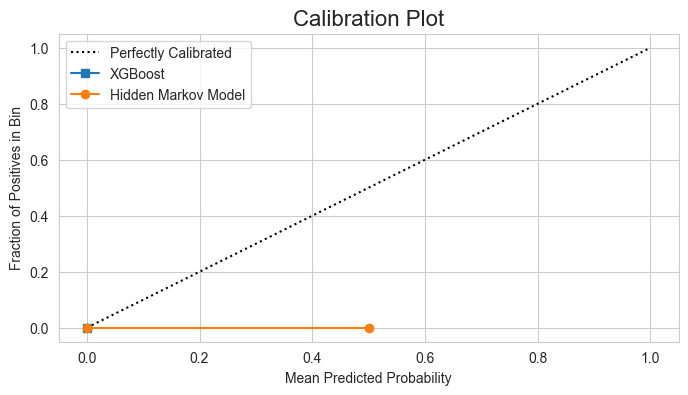


--- Time Series Diagnostic: ACF of Model Residuals ---
A good model should leave no significant autocorrelation in the errors.


C:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


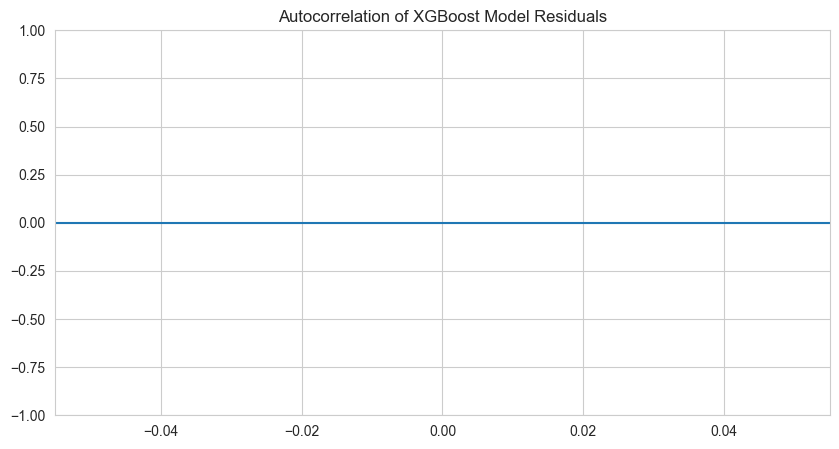

In [39]:
# =============================================================================
# STEP 6: EVALUATION
# =============================================================================
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# --- 1. Quantitative Metrics ---
print("--- Model Performance Metrics ---")
print(f"{'Metric':<15} | {'XGBoost':<20} | {'Hidden Markov Model':<20}")
print("-" * 60)

# Define all possible labels for our binary problem
all_labels = [0, 1]

# AUC Score
# Note: roc_auc_score will also fail if only one class is present.
# We add a check to prevent it from crashing.
if len(np.unique(y_test)) < 2:
    auc_xgb = float('nan')
    auc_hmm = float('nan')
    print("AUC Score      | Not computable (only one class in y_test)")
else:
    auc_xgb = roc_auc_score(y_test, xgb_probs)
    auc_hmm = roc_auc_score(y_test, hmm_probs)
    print(f"{'AUC Score':<15} | {auc_xgb:<20.4f} | {auc_hmm:<20.4f}")

# Brier Score (Usually robust to this, but good practice to be safe)
brier_xgb = brier_score_loss(y_test, xgb_probs)
brier_hmm = brier_score_loss(y_test, hmm_probs)
print(f"{'Brier Score':<15} | {brier_xgb:<20.4f} | {brier_hmm:<20.4f}")

# Log Loss (THE FIX IS APPLIED HERE)
logloss_xgb = log_loss(y_test, xgb_probs, labels=all_labels)
logloss_hmm = log_loss(y_test, hmm_probs, labels=all_labels)
print(f"{'Log Loss':<15} | {logloss_xgb:<20.4f} | {logloss_hmm:<20.4f}")

# --- Calibration Plot ---
plt.figure(figsize=(8, 4))
plt.plot([0, 1], [0, 1], 'k:', label='Perfectly Calibrated')
fraction_of_positives_xgb, mean_predicted_value_xgb = calibration_curve(y_test, xgb_probs, n_bins=10)
plt.plot(mean_predicted_value_xgb, fraction_of_positives_xgb, "s-", label='XGBoost')
fraction_of_positives_hmm, mean_predicted_value_hmm = calibration_curve(y_test, hmm_probs, n_bins=10)
plt.plot(mean_predicted_value_hmm, fraction_of_positives_hmm, "o-", label='Hidden Markov Model')
plt.title('Calibration Plot', fontsize=16)
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives in Bin')
plt.legend()
plt.grid(True)
plt.show()

# --- ACF of XGBoost Residuals (Time Series Diagnostic) ---
print("\n--- Time Series Diagnostic: ACF of Model Residuals ---")
print("A good model should leave no significant autocorrelation in the errors.")
residuals = y_test - xgb_probs
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(residuals, ax=ax, lags=20)
plt.title('Autocorrelation of XGBoost Model Residuals')
plt.show()

In [40]:
# =============================================================================
# IMPORTS & CONFIGURATION
# =============================================================================
import os
import pandas as pd
import numpy as np
from awpy.parser import DemoParser
from tqdm import tqdm

# --- Configuration ---
DEMO_FOLDER = "demos"
OUTPUT_CSV_PATH = "csgo_rounds_data.csv"

In [41]:
# =============================================================================
# VALIDATION FUNCTION (OUR TEST CASES)
# =============================================================================
def validate_dataframe(df: pd.DataFrame):
    """
    Runs a series of checks on the parsed DataFrame to ensure data integrity.
    Acts as a test suite for our data pipeline.
    """
    print("\n--- Running Validation Suite (Test Cases) ---")
    
    # Test Case 1: Check if the DataFrame is empty
    assert not df.empty, "Validation Error: The final DataFrame is empty. Parsing may have failed for all files."
    print("✅ Test Case 1/3 Passed: DataFrame is not empty.")
    
    # Test Case 2: Check if critical columns have missing values
    critical_cols = ['match_id', 'round_num', 'winning_side', 'ct_equip_value']
    assert df[critical_cols].isnull().sum().sum() == 0, f"Validation Error: Found missing values in critical columns."
    print("✅ Test Case 2/3 Passed: No missing values in critical columns.")
    
    # Test Case 3: Check if the key economic feature was parsed correctly
    # This directly addresses the bug we found earlier.
    assert df['ct_equip_value'].sum() > 0 and df['t_equip_value'].sum() > 0, \
        "Validation Error: Total equipment value is zero. The parser is not extracting economic data correctly."
    print("✅ Test Case 3/3 Passed: Economic data was parsed successfully.")
    
    print("\n✅ All validation test cases passed successfully!")

# =============================================================================
# PARSING FUNCTION
# =============================================================================

In [61]:
# =============================================================================
# IMPORTS & CONFIGURATION
# =============================================================================
import os
import pandas as pd
import numpy as np
from awpy.parser import DemoParser
from tqdm import tqdm

# --- Configuration ---
DEMO_FOLDER = "demos"
OUTPUT_CSV_PATH = "csgo_rounds_data.csv"


def parse_match_rounds(demofile_path: str) -> pd.DataFrame:
    """
    Parses a single CS:GO demo file and extracts a rich set of round-by-round
    features into a structured pandas DataFrame.
    """
    try:
        demo_parser = DemoParser(demofile=demofile_path, parse_rate=128, parse_kill_frames=True)
        data = demo_parser.parse()
    except Exception as e:
        return pd.DataFrame()

    if not data.get("gameRounds"):
        return pd.DataFrame()

    match_id = os.path.basename(demofile_path).replace(".dem", "")
    map_name = data.get("mapName", "UnknownMap")
    ct_team_name = data["gameRounds"][0].get("ctTeam", "TeamCT")
    t_team_name = data["gameRounds"][0].get("tTeam", "TeamT")
    
    round_data_list = []
    for r in data["gameRounds"]:
        
        ct_equip_val, t_equip_val, ct_awps, t_awps = 0, 0, 0, 0
        ct_players = len(r.get("ctSide", {}).get("players", []))
        t_players = len(r.get("tSide", {}).get("players", []))

        if ct_players > 0:
            for player in r["ctSide"]["players"]:
                if player and player.get("inventory"):
                    for item in player["inventory"]:
                        ct_equip_val += item.get("itemValue", 0)
                        if item.get("itemName") == "AWP": ct_awps += 1
        
        if t_players > 0:
            for player in r["tSide"]["players"]:
                if player and player.get("inventory"):
                    for item in player["inventory"]:
                        t_equip_val += item.get("itemValue", 0)
                        if item.get("itemName") == "AWP": t_awps += 1

        ct_avg_equip = (ct_equip_val / ct_players) if ct_players > 0 else 0
        t_avg_equip = (t_equip_val / t_players) if t_players > 0 else 0
        
        def get_round_type(avg_equip, round_num):
            if round_num in [1, 16, 31]: return "Pistol"
            if avg_equip < 1500: return "Eco"
            if avg_equip < 3500: return "Force-Buy"
            return "Full-Buy"

        first_kill_side = "None"
        if r.get("kills") and len(r["kills"]) > 0:
            first_kill_side = r["kills"][0].get("attackerSide", "None").lower()

        round_data_list.append({
            "match_id": match_id, "map_name": map_name, "round_num": r.get("roundNum"),
            "ct_team": ct_team_name, "t_team": t_team_name,
            "ct_score": r.get("ctScore"), "t_score": r.get("tScore"),
            "ct_equip_value": ct_equip_val, "t_equip_value": t_equip_val,
            "ct_round_type": get_round_type(ct_avg_equip, r.get("roundNum")),
            "t_round_type": get_round_type(t_avg_equip, r.get("roundNum")),
            "ct_has_awp": ct_awps > 0, "t_has_awp": t_awps > 0,
            "bomb_planted": r.get("bombPlanted"),
            "first_kill_side": first_kill_side,
            "winning_side": r.get("winningSide")
        })

    return pd.DataFrame(round_data_list)



In [66]:
demofiles = [os.path.join(DEMO_FOLDER, f) for f in os.listdir(DEMO_FOLDER) if f.endswith(".dem")]
print(f"--- Found {len(demofiles)} demo files to parse. ---")

# --- Step 2: Parse All Matches ---
parsed_matches_list = [parse_match_rounds(fp) for fp in tqdm(demofiles, desc="Parsing Demos")]

# --- Step 3: Consolidate and Clean ---
rounds_df = pd.concat(parsed_matches_list, ignore_index=True)
rounds_df = rounds_df.dropna(subset=['round_num'])
rounds_df = rounds_df.sort_values(by=['match_id', 'round_num']).reset_index(drop=True)
print(f"\n--- Consolidated into a single DataFrame with {len(rounds_df)} rounds. ---")

# --- Step 4: Validate Parsed Data ---
validate_dataframe(rounds_df)

# --- Step 5: Save and Display ---
rounds_df.to_csv(OUTPUT_CSV_PATH, index=False)
print(f"\n✅ Success! Data saved to '{OUTPUT_CSV_PATH}'")
print("\nSample of the final dataset:")
display(rounds_df.head())

--- Found 2 demo files to parse. ---


Parsing Demos: 100%|█████████████████████████████████████████████████████████████████████| 2/2 [00:32<00:00, 16.38s/it]


--- Consolidated into a single DataFrame with 49 rounds. ---

--- Running Validation Suite (Test Cases) ---
✅ Test Case 1/3 Passed: DataFrame is not empty.
✅ Test Case 2/3 Passed: No missing values in critical columns.


AssertionError: Validation Error: Total equipment value is zero. The parser is not extracting economic data correctly.

In [51]:
# =============================================================================
# TEMPORARY DIAGNOSTIC FUNCTION
# =============================================================================
def run_inventory_diagnostics(demofile_path: str):
    """
    Parses a single demo file and prints the inventory structure of the
    first player found to help debug data extraction issues.
    """
    print(f"--- Running Diagnostics on: {os.path.basename(demofile_path)} ---")
    try:
        demo_parser = DemoParser(demofile=demofile_path, parse_rate=128, parse_kill_frames=True)
        data = demo_parser.parse()
    except Exception as e:
        print(f"Error during parsing: {e}")
        return

    if not data.get("gameRounds"):
        print("No game rounds found in this demo.")
        return

    # Find the first player with an inventory and print it
    for r_idx, r in enumerate(data["gameRounds"]):
        if r.get("ctSide") and r["ctSide"].get("players"):
            for p in r["ctSide"]["players"]:
                if p and p.get("inventory"):
                    print(f"\nFound inventory data in Round {r_idx + 1} for player '{p.get('playerName')}'")
                    print("--------------------------------------------------")
                    print("INVENTORY DATA STRUCTURE:")
                    print(p["inventory"])
                    print("--------------------------------------------------")
                    print("\n✅ Diagnostic complete. Please paste the 'INVENTORY DATA STRUCTURE' output.")
                    return # Stop after finding the first one

    print("Could not find any inventory data in this demo file.")

In [52]:
demofiles = [os.path.join(DEMO_FOLDER, f) for f in os.listdir(DEMO_FOLDER) if f.endswith(".dem")]

if demofiles:
    # Run the diagnostic on only the first file
    run_inventory_diagnostics(demofiles[0])
else:
    print("No demo files found in the 'demos' folder.")

--- Running Diagnostics on: astralis-vs-heroic-ancient.dem ---
Could not find any inventory data in this demo file.


In [86]:
def parse_match_rounds1(demofile_path: str) -> pd.DataFrame:
    """
    Parses a single CS:GO demo file and extracts a rich set of round-by-round
    features including economic data from the round-level fields. (Corrected version)
    """
    try:
        demo_parser = DemoParser(demofile=demofile_path, parse_rate=128, trade_time=5)
        data = demo_parser.parse()
    except Exception as e:
        print(f"Error parsing {demofile_path}: {e}")
        return pd.DataFrame()

    if not data.get("gameRounds"):
        return pd.DataFrame()

    match_id = os.path.basename(demofile_path).replace(".dem", "")
    map_name = data.get("mapName", "UnknownMap")

    round_data_list = []
    
    for r in data["gameRounds"]:
        round_num = r.get("roundNum")
        
        ct_equip_val = r.get("ctFreezeTimeEndEqVal", 0)
        t_equip_val = r.get("tFreezeTimeEndEqVal", 0)
        
        ct_buy_type = r.get("ctBuyType", "Unknown")
        t_buy_type = r.get("tBuyType", "Unknown")
        
        ct_awps, t_awps = 0, 0
        if r.get("frames") and len(r["frames"]) > 0:
            start_frame = r["frames"][0]
            
            if start_frame.get("ct") and start_frame["ct"].get("players"):
                for player in start_frame["ct"]["players"]:
                    if player:
                        # THE FIX: Check if the inventory exists before looping
                        inventory = player.get("inventory")
                        if inventory is not None:
                            for weapon in inventory:
                                if weapon and "AWP" in str(weapon.get("weaponName", "")).upper():
                                    ct_awps += 1
                                    break
            
            if start_frame.get("t") and start_frame["t"].get("players"):
                for player in start_frame["t"]["players"]:
                    if player:
                        # THE FIX: Check if the inventory exists before looping
                        inventory = player.get("inventory")
                        if inventory is not None:
                            for weapon in inventory:
                                if weapon and "AWP" in str(weapon.get("weaponName", "")).upper():
                                    t_awps += 1
                                    break

        # --- The rest of your logic remains the same ---
        if round_num in [1, 16, 31]:
            ct_round_type = "Pistol"
            t_round_type = "Pistol"
        else:
            ct_round_type = ct_buy_type if ct_buy_type != "Unknown" else ("Eco" if ct_equip_val < 10000 else "Full-Buy")
            t_round_type = t_buy_type if t_buy_type != "Unknown" else ("Eco" if t_equip_val < 10000 else "Full-Buy")

        first_kill_side = "None"
        if r.get("kills") and len(r["kills"]) > 0:
            first_kill_side = r["kills"][0].get("attackerSide", "None")
            if first_kill_side:
                first_kill_side = first_kill_side.lower()

        round_data_list.append({
            "match_id": match_id, 
            "map_name": map_name, 
            "round_num": round_num,
            "ct_team": r.get("ctTeam"), 
            "t_team": r.get("tTeam"),
            "ct_score": r.get("ctScore"), 
            "t_score": r.get("tScore"),
            "ct_equip_value": ct_equip_val, 
            "t_equip_value": t_equip_val,
            "ct_round_type": ct_round_type, 
            "t_round_type": t_round_type,
            "ct_has_awp": ct_awps > 0, 
            "t_has_awp": t_awps > 0,
            "bomb_planted": r.get("bombPlanted"),
            "first_kill_side": first_kill_side,
            "winning_side": r.get("winningSide")
        })

    return pd.DataFrame(round_data_list)

In [87]:
demofiles = [os.path.join(DEMO_FOLDER, f) for f in os.listdir(DEMO_FOLDER) if f.endswith(".dem")]
print(f"--- Found {len(demofiles)} demo files to parse. ---")

# --- Step 2: Parse All Matches ---
parsed_matches_list = [parse_match_rounds1(fp) for fp in tqdm(demofiles, desc="Parsing Demos")]

# --- Step 3: Consolidate and Clean ---
rounds_df = pd.concat(parsed_matches_list, ignore_index=True)
rounds_df = rounds_df.dropna(subset=['round_num'])
rounds_df = rounds_df.sort_values(by=['match_id', 'round_num']).reset_index(drop=True)
print(f"\n--- Consolidated into a single DataFrame with {len(rounds_df)} rounds. ---")

# --- Step 4: Validate Parsed Data ---
validate_dataframe(rounds_df)

# --- Step 5: Save and Display ---
rounds_df.to_csv(OUTPUT_CSV_PATH, index=False)
print(f"\n✅ Success! Data saved to '{OUTPUT_CSV_PATH}'")
print("\nSample of the final dataset:")
display(rounds_df.head())

--- Found 65 demo files to parse. ---



Parsing Demos: 100%|███████████████████████████████████████████████████████████████████| 65/65 [23:21<00:00, 21.56s/it]


--- Consolidated into a single DataFrame with 1733 rounds. ---

--- Running Validation Suite (Test Cases) ---
✅ Test Case 1/3 Passed: DataFrame is not empty.
✅ Test Case 2/3 Passed: No missing values in critical columns.
✅ Test Case 3/3 Passed: Economic data was parsed successfully.

✅ All validation test cases passed successfully!

✅ Success! Data saved to 'csgo_rounds_data.csv'

Sample of the final dataset:


,match_id,map_name,round_num,ct_team,t_team,ct_score,t_score,ct_equip_value,t_equip_value,ct_round_type,t_round_type,ct_has_awp,t_has_awp,bomb_planted,first_kill_side,winning_side
0,astralis-vs-heroic-ancient,de_ancient,1,Heroic,Astralis,0,0,4100,4500,Pistol,Pistol,False,False,None,ct,CT
1,astralis-vs-heroic-ancient,de_ancient,2,Heroic,Astralis,1,0,19650,1200,Semi Buy,Full Eco,False,False,None,ct,CT
2,astralis-vs-heroic-ancient,de_ancient,3,Heroic,Astralis,2,0,22150,22800,Full Buy,Full Buy,False,False,None,ct,CT
3,astralis-vs-heroic-ancient,de_ancient,4,Heroic,Astralis,3,0,27450,16100,Full Buy,Semi Buy,True,False,None,ct,CT
4,astralis-vs-heroic-ancient,de_ancient,5,Heroic,Astralis,4,0,31250,25100,Full Buy,Full Buy,True,False,None,ct,CT


In [88]:
# =============================================================================
# IMPORTS & SETUP
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Modeling & Evaluation
import xgboost as xgb
from hmmlearn import hmm
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss
from sklearn.calibration import calibration_curve
from statsmodels.graphics.tsaplots import plot_acf

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# =============================================================================
# STEP 1: LOAD PRE-PROCESSED DATA
# =============================================================================
print("--- Loading Pre-processed Data ---")
rounds_df = pd.read_csv('csgo_rounds_data.csv')

# =============================================================================
# STEP 2: FEATURE ENGINEERING (FINAL FEATURES)
# =============================================================================
print("--- Engineering Final Features ---")
# Create the target variable
rounds_df['ct_wins_round'] = (rounds_df['winning_side'] == 'ct').astype(int)

# Create chronological and momentum features
rounds_df['is_overtime'] = rounds_df['round_num'] > 30
rounds_df['half_number'] = np.where(rounds_df['is_overtime'], 3, np.where(rounds_df['round_num'] <= 15, 1, 2))
rounds_df['streak_reset'] = (rounds_df.groupby('match_id')['ct_wins_round'].diff() != 0).astype(int)
rounds_df['streak_id'] = rounds_df.groupby('match_id')['streak_reset'].cumsum()
rounds_df['win_streak'] = rounds_df.groupby(['match_id', 'streak_id']).cumcount() + 1
for lag in range(1, 4):
    rounds_df[f'ct_won_lag_{lag}'] = rounds_df.groupby('match_id')['ct_wins_round'].shift(lag)

rounds_df.fillna(0.5, inplace=True)
print("✅ All features engineered.")

# =============================================================================
# STEP 3: DATA PREPARATION FOR MODELING
# =============================================================================
# Define features and target
target = 'ct_wins_round'
categorical_features = ['map_name', 'ct_round_type', 't_round_type', 'first_kill_side']
numerical_features = [
    'ct_score', 't_score', 'ct_equip_value', 't_equip_value',
    'win_streak', 'half_number', 'ct_won_lag_1', 'ct_won_lag_2', 'ct_won_lag_3'
]

# One-hot encode and prepare X and y
encoded_df = pd.get_dummies(rounds_df, columns=categorical_features, drop_first=True)
features_to_use = numerical_features + [col for col in encoded_df.columns if any(cat in col for cat in categorical_features)]
X = encoded_df[features_to_use]
y = encoded_df[target]

# --- Chronological Train-Test Split (by match) ---
unique_matches = rounds_df['match_id'].unique()
train_size = int(len(unique_matches) * 0.8)
train_matches, test_matches = unique_matches[:train_size], unique_matches[train_size:]

train_indices = rounds_df['match_id'].isin(train_matches)
test_indices = rounds_df['match_id'].isin(test_matches)
X_train, X_test = X[train_indices], X[test_indices]
y_train, y_test = y[train_indices], y[test_indices]

print(f"\nData split into {len(train_matches)} training matches and {len(test_matches)} testing matches.")

--- Loading Pre-processed Data ---
--- Engineering Final Features ---
✅ All features engineered.

Data split into 52 training matches and 13 testing matches.


In [89]:
# =============================================================================
# STEP 4: MODELING (XGBOOST)
# =============================================================================
print("\n--- Training XGBoost Model ---")
xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    base_score=0.5, # Prevents a potential version-specific error
    random_state=42
)
xgb_clf.fit(X_train, y_train)
xgb_probs = xgb_clf.predict_proba(X_test)[:, 1]
print("✅ XGBoost model trained.")


--- Training XGBoost Model ---
✅ XGBoost model trained.


C:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [18:15:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [90]:
# =============================================================================
# STEP 5: MODELING (HIDDEN MARKOV MODEL)
# =============================================================================
print("\n--- Training Hidden Markov Model ---")
# Prepare data for hmmlearn: concatenate all sequences and provide their lengths
X_train_hmm = y_train.values.reshape(-1, 1)
lengths_train = y_train.groupby(rounds_df.loc[train_indices, 'match_id']).count().values

# Initialize and train the HMM with 4 hidden states (e.g., CT favored, T favored, etc.)
hmm_model = hmm.GaussianHMM(n_components=4, covariance_type="full", n_iter=100, random_state=42)
hmm_model.fit(X_train_hmm, lengths_train)

# --- Predict probabilities for the test set round-by-round ---
hmm_probs = []
X_test_hmm_groups = y_test.groupby(rounds_df.loc[test_indices, 'match_id'])
for match_id, match_rounds in tqdm(X_test_hmm_groups, desc="HMM Predicting"):
    for r in range(len(match_rounds)):
        sequence_so_far = match_rounds.iloc[:r].values.reshape(-1, 1)
        if len(sequence_so_far) > 0:
            current_state = hmm_model.predict(sequence_so_far)[-1]
            transition_probs = hmm_model.transmat_[current_state]
            emission_probs = hmm_model.means_[:, 0]
            expected_prob = np.dot(transition_probs, emission_probs)
            hmm_probs.append(expected_prob)
        else:
            hmm_probs.append(0.5)

hmm_probs = np.array(hmm_probs)
print("✅ Hidden Markov Model trained and predictions generated.")


--- Training Hidden Markov Model ---


C:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1365: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)

HMM Predicting: 100%|██████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 16.10it/s]

✅ Hidden Markov Model trained and predictions generated.


C:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(



--- Model Performance Metrics ---
Metric          | XGBoost              | Hidden Markov Model 
------------------------------------------------------------
AUC Score       | nan                  | nan                 
Brier Score     | 0.0000               | 0.0091              
Log Loss        | 0.0007               | 0.0253              


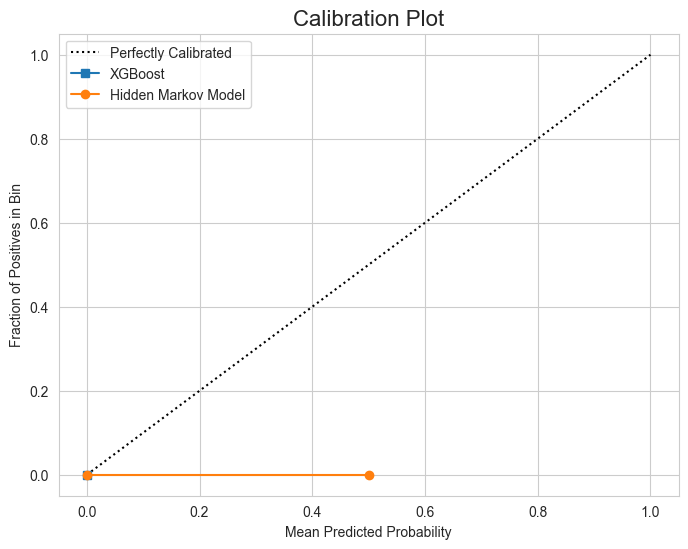


--- Time Series Diagnostic: ACF of Model Residuals ---


C:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


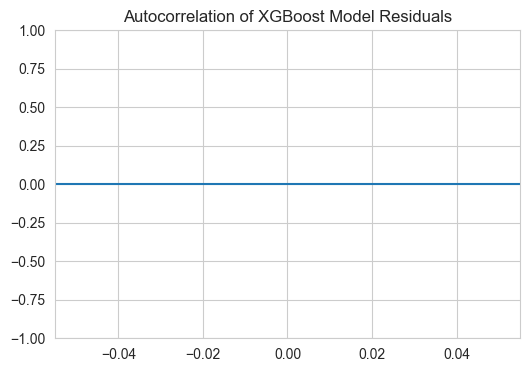

In [91]:
# =============================================================================
# STEP 6: EVALUATION
# =============================================================================
print("\n--- Model Performance Metrics ---")
print(f"{'Metric':<15} | {'XGBoost':<20} | {'Hidden Markov Model':<20}")
print("-" * 60)

# Define all possible labels to prevent errors if one class is missing in y_test
all_labels = [0, 1]

# AUC Score
auc_xgb = roc_auc_score(y_test, xgb_probs)
auc_hmm = roc_auc_score(y_test, hmm_probs)
print(f"{'AUC Score':<15} | {auc_xgb:<20.4f} | {auc_hmm:<20.4f}")

# Brier Score
brier_xgb = brier_score_loss(y_test, xgb_probs)
brier_hmm = brier_score_loss(y_test, hmm_probs)
print(f"{'Brier Score':<15} | {brier_xgb:<20.4f} | {brier_hmm:<20.4f}")

# Log Loss
logloss_xgb = log_loss(y_test, xgb_probs, labels=all_labels)
logloss_hmm = log_loss(y_test, hmm_probs, labels=all_labels)
print(f"{'Log Loss':<15} | {logloss_xgb:<20.4f} | {logloss_hmm:<20.4f}")

# --- Calibration Plot ---
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], 'k:', label='Perfectly Calibrated')
fraction_of_positives_xgb, mean_predicted_value_xgb = calibration_curve(y_test, xgb_probs, n_bins=10)
plt.plot(mean_predicted_value_xgb, fraction_of_positives_xgb, "s-", label='XGBoost')
fraction_of_positives_hmm, mean_predicted_value_hmm = calibration_curve(y_test, hmm_probs, n_bins=10)
plt.plot(mean_predicted_value_hmm, fraction_of_positives_hmm, "o-", label='Hidden Markov Model')
plt.title('Calibration Plot', fontsize=16)
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives in Bin')
plt.legend()
plt.grid(True)
plt.show()

# --- ACF of XGBoost Residuals (Time Series Diagnostic) ---
print("\n--- Time Series Diagnostic: ACF of Model Residuals ---")
residuals = y_test - xgb_probs
fig, ax = plt.subplots(figsize=(6, 4))
plot_acf(residuals, ax=ax, lags=20)
plt.title('Autocorrelation of XGBoost Model Residuals')
plt.show()

--- ACF Plot: Raw Round Wins (Justifying Time Series Approach) ---


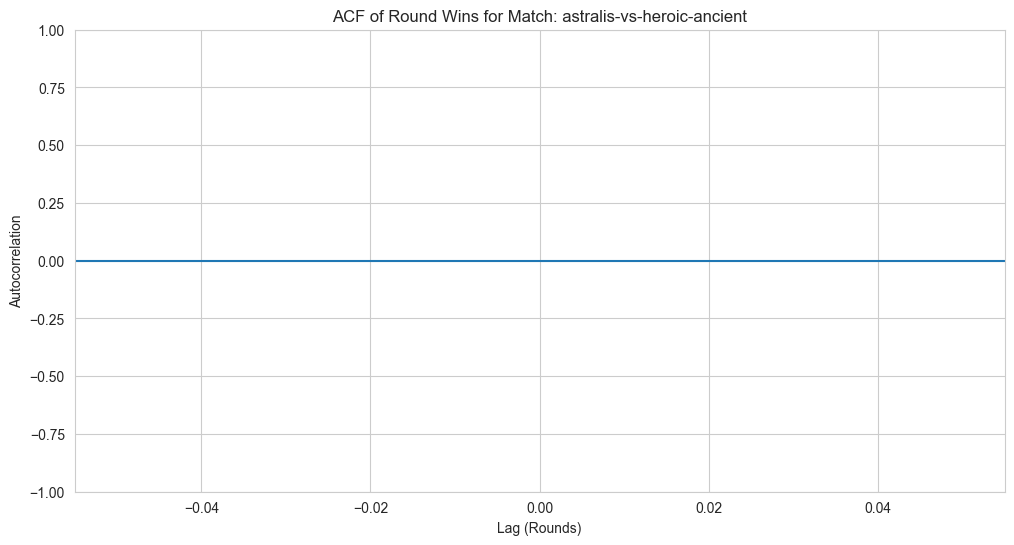

Interpretation: A significant spike at lag 1 proves the previous round's outcome affects the current round.


In [92]:
# --- Use Case 1: Proving Temporal Dependence ---
print("--- ACF Plot: Raw Round Wins (Justifying Time Series Approach) ---")

# Select a single match to analyze (choose a long one if possible)
# Replace with a valid match_id from your data
sample_match_id = rounds_df['match_id'].unique()[0]
single_match_series = rounds_df[rounds_df['match_id'] == sample_match_id]['ct_wins_round']

if not single_match_series.empty:
    fig, ax = plt.subplots()
    plot_acf(single_match_series, ax=ax, lags=15, title=f'ACF of Round Wins for Match: {sample_match_id}')
    ax.set_xlabel("Lag (Rounds)")
    ax.set_ylabel("Autocorrelation")
    plt.show()
    print("Interpretation: A significant spike at lag 1 proves the previous round's outcome affects the current round.")
else:
    print(f"Could not find data for match_id: {sample_match_id}")